# Problem 2: Clan Rank Regression - EDA

## Diagnostic and comparison of full and trophy-free dataset variants

This notebook analyzes the dataset for **Problem 2: Clan Rank Regression**. It evaluates two variants: the full dataset including direct trophy metrics, and a trophy-free variant built solely from clan composition, activity, and progression signals.

## 1. Setup and Dynamic Data Loading

Libraries are imported and plotting styles are configured. The project root is located dynamically, the dataset is loaded, and two DataFrame views are created: `df_full` and `df_no_trophies`.

In [1]:
# === 1. Setup and Dynamic Data Loading ===
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.feature_selection import mutual_info_regression
from pathlib import Path
from collections import defaultdict

sns.set_theme(style='whitegrid', palette='viridis')
%matplotlib inline

def find_project_root() -> Path:
    """Locate the project root by searching for the Problem 2 datasets."""
    candidates = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
    for cand in candidates:
        if (cand / 'data' / 'datasets' / 'clan_rank_regression_with_trophies.parquet').exists():
            return cand
    raise FileNotFoundError(
        'Could not find data/datasets/clan_rank_regression_with_trophies.parquet. '
        'Adjust the path or run the notebook from the project root.'
    )

root = find_project_root()
PATH_WITH_TROPHIES = root / 'data' / 'datasets' / 'clan_rank_regression_with_trophies.parquet'
PATH_WITHOUT_TROPHIES = root / 'data' / 'datasets' / 'clan_rank_regression_without_trophies.parquet'

print(f'Project root directory: {root}')
print(f'Full dataset path: {PATH_WITH_TROPHIES}')
print(f'Trophy-free dataset path: {PATH_WITHOUT_TROPHIES}')

# Load both dataset variants directly
df_full = pd.read_parquet(PATH_WITH_TROPHIES)
df_no_trophies = pd.read_parquet(PATH_WITHOUT_TROPHIES)

TARGET = 'clan_rank'

# Identify trophy columns that exist in df_full but not in df_no_trophies for logging
trophy_cols = list(set(df_full.columns) - set(df_no_trophies.columns))
print('')
print(f'Excluded trophy-related columns in trophy-free variant: {trophy_cols}')

print('')
print(f'Full variant shape: {df_full.shape}')
print(f'Trophy-free variant shape: {df_no_trophies.shape}')
df_full.head()

Project root directory: c:\Users\Usuario\Desktop\Clash of Clans ML Lab
Full dataset path: c:\Users\Usuario\Desktop\Clash of Clans ML Lab\data\datasets\clan_rank_regression_with_trophies.parquet
Trophy-free dataset path: c:\Users\Usuario\Desktop\Clash of Clans ML Lab\data\datasets\clan_rank_regression_without_trophies.parquet

Excluded trophy-related columns in trophy-free variant: ['required_trophies', 'best_trophies', 'trophies_diff_from_clan_mean', 'trophies', 'clan_mean_trophies', 'progression_ratio_trophies', 'trophies_clan_pct', 'trophies_ratio_to_clan_mean']

Full variant shape: (837411, 87)
Trophy-free variant shape: (837411, 79)


,player_tag,clan_tag,name,town_hall_level,exp_level,league_id,league_name,league_tier_id,league_tier_name,trophies,...,war_stars_diff_from_clan_mean,war_stars_ratio_to_clan_mean,war_stars_clan_pct,attack_wins_diff_from_clan_mean,attack_wins_ratio_to_clan_mean,attack_wins_clan_pct,defense_wins_diff_from_clan_mean,defense_wins_ratio_to_clan_mean,defense_wins_clan_pct,clan_rank
0,#Y8GGPRUPR,#200022JVL,F A N,18,270,29000022,Legend League,105000035,Legend II,1218,...,1235.020408,1.550125,0.857143,26.795918,9.363057,1.000000,0.55102,2.227273,0.857143,1
1,#9PQV8JPCP,#200022JVL,Dark to,18,249,29000000,Unranked,105000035,Legend II,1045,...,1274.020408,1.567498,0.897959,-3.204082,0.000000,0.387755,-0.44898,0.000000,0.397959,2
2,#P8RLQVJL,#200022JVL,Aerox,18,291,29000022,Legend League,105000035,Legend II,859,...,4128.020408,2.838779,1.000000,16.795918,6.242038,0.959184,-0.44898,0.000000,0.397959,3
3,#2VU80892Y,#200022JVL,"Prof,D,Bijoxz",18,266,29000022,Legend League,105000035,Legend II,674,...,1210.020408,1.538989,0.836735,12.795918,4.993631,0.918367,-0.44898,0.000000,0.397959,4
4,#98CPPQYUC,#200022JVL,Majestic.,18,250,29000000,Unranked,105000035,Legend II,112,...,372.020408,1.165712,0.632653,-3.204082,0.000000,0.387755,-0.44898,0.000000,0.397959,5


## 2. Data Integrity and Quality Audit

Dimensions, data types, missing values, duplicate rows, and quasi-constant features are audited for both variants.

In [2]:
# === 2. Data Integrity and Quality Audit ===

def audit_dataframe(data: pd.DataFrame, name: str) -> None:
    """Prints basic integrity metrics for a DataFrame."""
    print('')
    print(f'=== {name} ===')
    print(f'Dimensions: {data.shape[0]} rows x {data.shape[1]} columns')
    print('')
    print('Data types:')
    display(data.dtypes.to_frame(name='dtype'))
    missing = data.isna().sum()
    missing_pct = (missing / len(data)) * 100
    missing_df = pd.DataFrame({'missing': missing, 'percentage': missing_pct})
    print('')
    print('Missing values (columns with missing > 0):')
    display(missing_df[missing_df['missing'] > 0].sort_values('percentage', ascending=False))
    dup_rows = data.duplicated().sum()
    print('')
    print(f'Exact duplicate rows: {dup_rows}')
    threshold = 0.95
    constant_features = []
    for col in data.columns:
        value_counts = data[col].value_counts(dropna=False)
        top_freq = value_counts.iloc[0] / len(data) if len(value_counts) > 0 else 1.0
        if top_freq >= threshold:
            constant_features.append((col, 'nearly_constant', top_freq))
        if pd.api.types.is_numeric_dtype(data[col]) and data[col].nunique(dropna=True) <= 1:
            constant_features.append((col, 'zero_variance', top_freq))
    if constant_features:
        print('')
        print(f'Quasi-constant or zero-variance features (threshold={threshold}):')
        display(pd.DataFrame(constant_features, columns=['column', 'type', 'mode_frequency']))
    else:
        print('')
        print(f'No quasi-constant features with mode frequency >= {threshold}.')

audit_dataframe(df_full, 'Full Dataset')
audit_dataframe(df_no_trophies, 'Trophy-Free Dataset')


=== Full Dataset ===
Dimensions: 837411 rows x 87 columns

Data types:


,dtype
player_tag,str
clan_tag,str
name,str
town_hall_level,int64
exp_level,int64
...,...
attack_wins_clan_pct,float64
defense_wins_diff_from_clan_mean,float64
defense_wins_ratio_to_clan_mean,float64
defense_wins_clan_pct,float64



Missing values (columns with missing > 0):


,missing,percentage
capital_contributions,837411,100.0
clan_mean_capital_contributions,837411,100.0



Exact duplicate rows: 0

Quasi-constant or zero-variance features (threshold=0.95):


...

,dtype
player_tag,str
clan_tag,str
name,str
town_hall_level,int64
exp_level,int64
...,...
attack_wins_clan_pct,float64
defense_wins_diff_from_clan_mean,float64
defense_wins_ratio_to_clan_mean,float64
defense_wins_clan_pct,float64



Missing values (columns with missing > 0):


,missing,percentage
capital_contributions,837411,100.0
clan_mean_capital_contributions,837411,100.0



Exact duplicate rows: 0

Quasi-constant or zero-variance features (threshold=0.95):


,column,type,mode_frequency
0,capital_contributions,nearly_constant,1.000000
1,capital_contributions,zero_variance,1.000000
2,attack_wins,nearly_constant,0.977350
3,defense_wins,nearly_constant,0.961056
4,combat_activity_total,nearly_constant,0.956284
5,achievement_count,nearly_constant,1.000000
6,achievement_count,zero_variance,1.000000
7,clan_mean_capital_contributions,nearly_constant,1.000000
8,clan_mean_capital_contributions,zero_variance,1.000000
9,capital_contributions_diff_from_clan_mean,nearly_constant,1.000000


## 3. Target Analysis (`clan_rank`)

Descriptive statistics, distribution plots in raw and log-transformed scale, and skewness diagnostics are performed for the target variable.

=== Descriptive statistics for clan_rank ===
count    837411.000000
mean         13.780303
std          11.250930
min           1.000000
25%           5.000000
50%          10.000000
75%          20.000000
max          50.000000

Skewness: 1.0297
Kurtosis: 0.3160


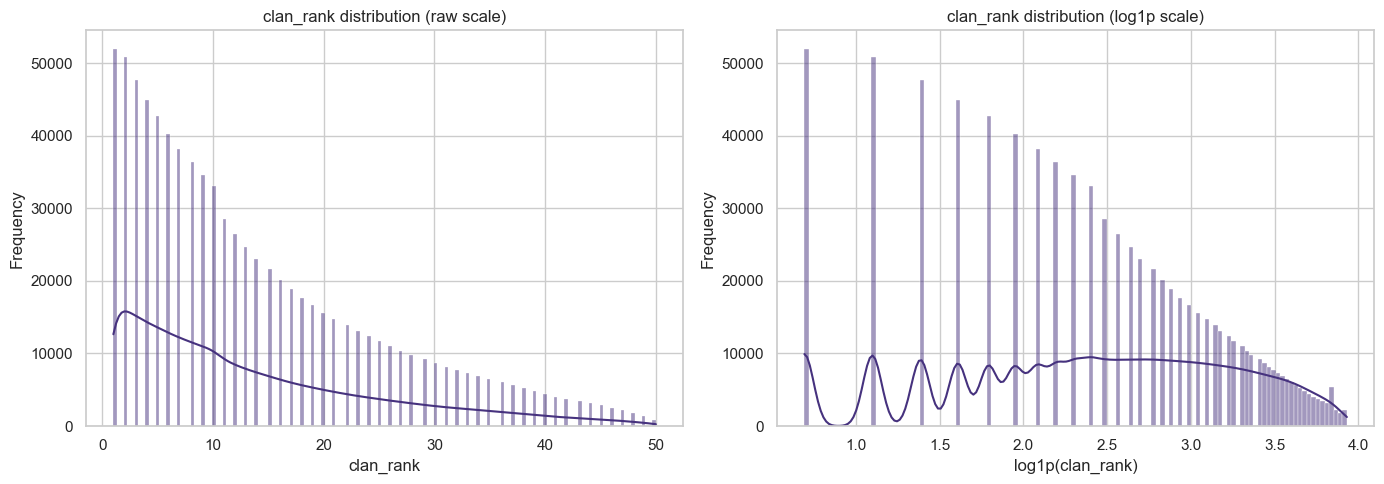

The clan_rank distribution is highly skewed. A log1p transformation is recommended before modeling.


In [3]:
# === 3. Target Analysis (clan_rank) ===

target = df_full[TARGET].copy()
print('=== Descriptive statistics for clan_rank ===')
print(target.describe().to_string())
print('')
skewness = stats.skew(target.dropna())
kurtosis = stats.kurtosis(target.dropna())
print(f'Skewness: {skewness:.4f}')
print(f'Kurtosis: {kurtosis:.4f}')

# Raw scale distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(target, kde=True, ax=axes[0])
axes[0].set_title('clan_rank distribution (raw scale)')
axes[0].set_xlabel('clan_rank')
axes[0].set_ylabel('Frequency')

# Log-transformed scale
log_target = np.log1p(target)
sns.histplot(log_target, kde=True, ax=axes[1])
axes[1].set_title('clan_rank distribution (log1p scale)')
axes[1].set_xlabel('log1p(clan_rank)')
axes[1].set_ylabel('Frequency')
plt.tight_layout()
plt.show()

# Log-transform recommendation
if abs(skewness) > 1.0:
    print('The clan_rank distribution is highly skewed. A log1p transformation is recommended before modeling.')
elif abs(skewness) > 0.5:
    print('The clan_rank distribution is moderately skewed. A log1p transformation may improve model performance.')
else:
    print('The clan_rank distribution is approximately symmetric. No transformation is strictly required.')

## 4. Feature Group Profiling

Variables are classified into conceptual groups: **Progression**, **Activity**, **Economy**, **Trophies/Competition**, and **Clan Composition**. Skewness, zero-value ratio, and missing percentage are reported for each numerical feature.

In [4]:
# === 4. Feature Group Profiling ===

def categorize_feature(col: str) -> str:
    """Assigns a feature to a conceptual group based on its name."""
    col_l = col.lower()
    if any(k in col_l for k in ['troop', 'hero', 'spell', 'equipment', 'builder_hall', 'town_hall', 'exp_level', 'achievement']):
        return 'Progression'
    if any(k in col_l for k in ['donat', 'attack', 'defense', 'war_stars', 'versus_battle']):
        return 'Activity'
    if any(k in col_l for k in ['loot', 'gold', 'elixir', 'dark_elixir', 'clan_games']):
        return 'Economy'
    if any(k in col_l for k in ['troph', 'points', 'league', 'legend']):
        return 'Trophies/Competition'
    if any(k in col_l for k in ['members', 'clan_', 'count', 'composition', 'size']):
        return 'Clan Composition'
    return 'Other'

def profile_numeric_features(data: pd.DataFrame, name: str) -> pd.DataFrame:
    """Computes skewness, zero ratio and missing ratio for numeric columns."""
    numeric_cols = data.select_dtypes(include=[np.number]).columns.tolist()
    if TARGET in numeric_cols:
        numeric_cols.remove(TARGET)
    records = []
    for col in numeric_cols:
        series = data[col]
        records.append({
            'feature': col,
            'group': categorize_feature(col),
            'skewness': series.skew(),
            'zero_pct': (series == 0).mean() * 100,
            'missing_pct': series.isna().mean() * 100
        })
    profile = pd.DataFrame(records).sort_values('skewness', key=lambda s: s.abs(), ascending=False)
    print('')
    print(f'=== Numerical feature profile for {name} ===')
    display(profile)
    return profile

profile_full = profile_numeric_features(df_full, 'Full Dataset')
profile_no_trophies = profile_numeric_features(df_no_trophies, 'Trophy-Free Dataset')


=== Numerical feature profile for Full Dataset ===


,feature,group,skewness,zero_pct,missing_pct
17,donation_ratio,Activity,883.319323,80.792108,0.0
6,donations,Activity,391.451202,73.309522,0.0
58,donations_diff_from_clan_mean,Activity,365.867884,30.106722,0.0
16,donation_balance,Activity,349.795288,65.915900,0.0
7,donations_received,Activity,151.424792,73.063884,0.0
...,...,...,...,...,...
66,capital_contributions_clan_pct,Clan Composition,0.000000,100.000000,0.0
64,capital_contributions_diff_from_clan_mean,Clan Composition,0.000000,100.000000,0.0
65,capital_contributions_ratio_to_clan_mean,Clan Composition,0.000000,100.000000,0.0
8,capital_contributions,Other,NaN,0.000000,100.0



=== Numerical feature profile for Trophy-Free Dataset ===


,feature,group,skewness,zero_pct,missing_pct
15,donation_ratio,Activity,883.319323,80.792108,0.0
5,donations,Activity,391.451202,73.309522,0.0
50,donations_diff_from_clan_mean,Activity,365.867884,30.106722,0.0
14,donation_balance,Activity,349.795288,65.915900,0.0
6,donations_received,Activity,151.424792,73.063884,0.0
...,...,...,...,...,...
58,capital_contributions_clan_pct,Clan Composition,0.000000,100.000000,0.0
56,capital_contributions_diff_from_clan_mean,Clan Composition,0.000000,100.000000,0.0
57,capital_contributions_ratio_to_clan_mean,Clan Composition,0.000000,100.000000,0.0
7,capital_contributions,Other,NaN,0.000000,100.0


## 5. Feature-Target Relationships (Regression)

For each variant, Mutual Information, Pearson correlation, and Spearman correlation with `clan_rank` are computed. Scatter plots are shown for the top 6 features by Mutual Information.


=== Feature-target metrics for Full Dataset ===
Top 10 Mutual Information:


,feature,mutual_info
0,members,0.467676
1,attack_wins_clan_pct,0.423052
2,town_hall_level_clan_pct,0.419419
3,defense_wins_clan_pct,0.388326
4,exp_level_clan_pct,0.352160
5,donations_clan_pct,0.348760
6,donations_received_clan_pct,0.308286
7,town_hall_level_diff_from_clan_mean,0.286278
8,war_stars_clan_pct,0.281213
9,trophies_clan_pct,0.276252



Top 10 Pearson correlation:


,feature,pearson_r
0,members,0.633797
1,clan_capital_points,0.460138
2,clan_points,0.454273
3,town_hall_level_clan_pct,-0.420877
4,exp_level_clan_pct,-0.382472
5,donations_clan_pct,-0.360929
6,clan_level,0.357667
7,clan_mean_town_hall_level,0.341561
8,war_stars_clan_pct,-0.337008
9,exp_level_diff_from_clan_mean,-0.330000



Top 10 Spearman correlation:


,feature,spearman_r
0,members,0.620904
1,attack_wins_clan_pct,-0.568895
2,defense_wins_clan_pct,-0.515443
3,clan_points,0.490260
4,town_hall_level_clan_pct,-0.481195
5,clan_capital_points,0.456444
6,donations_clan_pct,-0.442348
7,exp_level_clan_pct,-0.441006
8,donations_diff_from_clan_mean,-0.410980
9,town_hall_level_diff_from_clan_mean,-0.402084


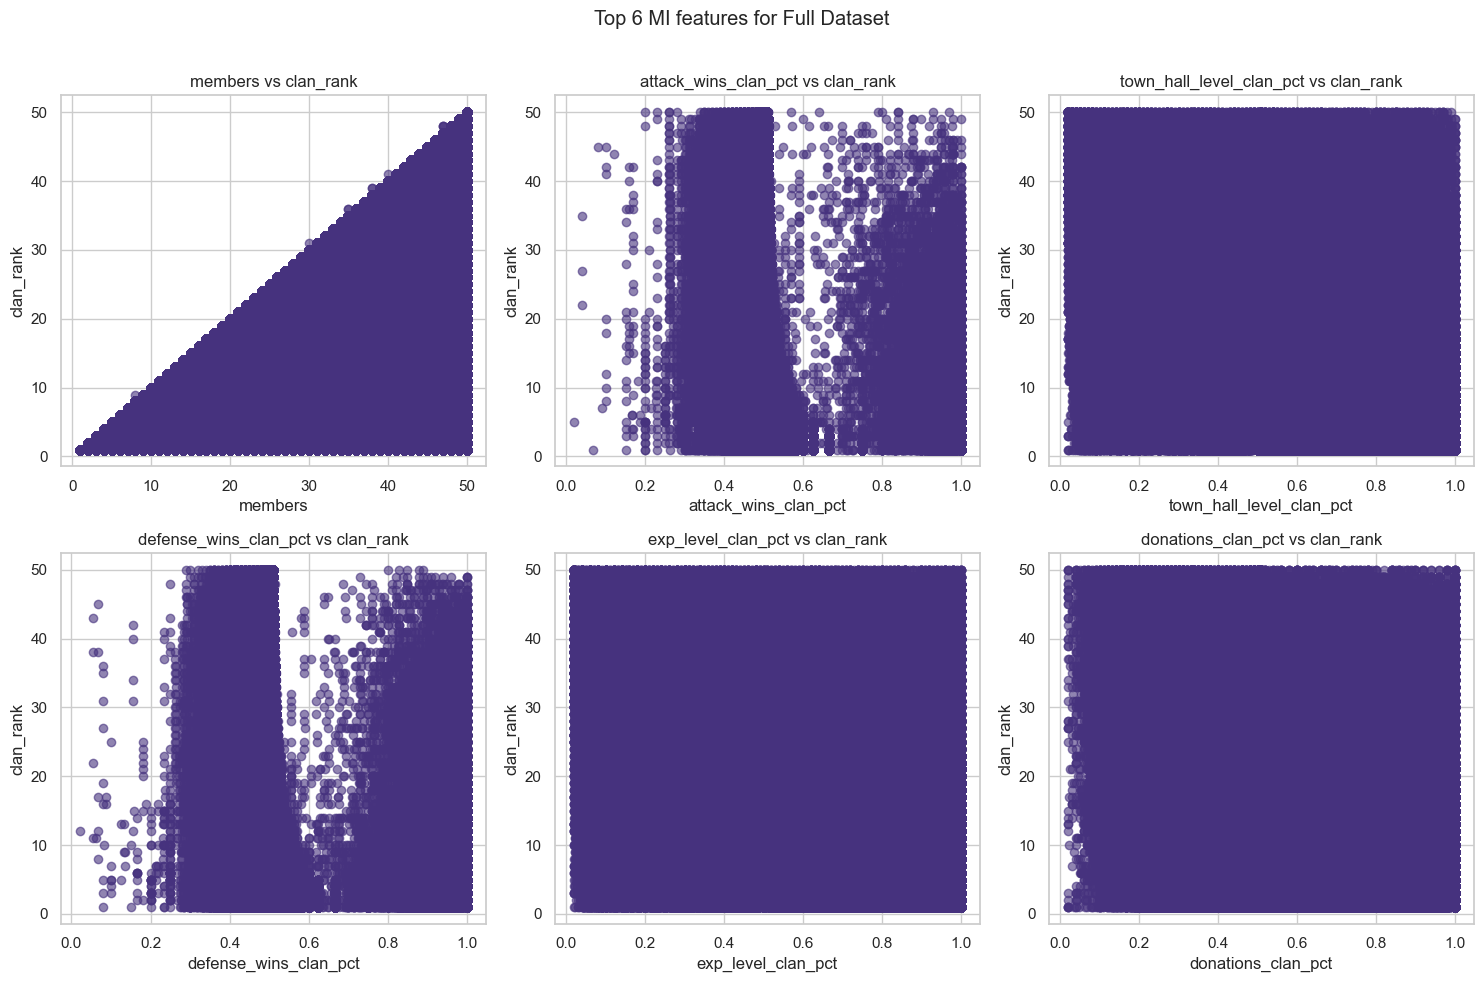


=== Feature-target metrics for Trophy-Free Dataset ===
Top 10 Mutual Information:


,feature,mutual_info
0,members,0.468411
1,attack_wins_clan_pct,0.420851
2,town_hall_level_clan_pct,0.418714
3,defense_wins_clan_pct,0.389441
4,exp_level_clan_pct,0.353433
5,donations_clan_pct,0.349768
6,donations_received_clan_pct,0.307359
7,town_hall_level_diff_from_clan_mean,0.286037
8,war_stars_clan_pct,0.282604
9,town_hall_level_ratio_to_clan_mean,0.203446



Top 10 Pearson correlation:


,feature,pearson_r
0,members,0.633797
1,clan_capital_points,0.460138
2,clan_points,0.454273
3,town_hall_level_clan_pct,-0.420877
4,exp_level_clan_pct,-0.382472
5,donations_clan_pct,-0.360929
6,clan_level,0.357667
7,clan_mean_town_hall_level,0.341561
8,war_stars_clan_pct,-0.337008
9,exp_level_diff_from_clan_mean,-0.330000



Top 10 Spearman correlation:


,feature,spearman_r
0,members,0.620904
1,attack_wins_clan_pct,-0.568895
2,defense_wins_clan_pct,-0.515443
3,clan_points,0.490260
4,town_hall_level_clan_pct,-0.481195
5,clan_capital_points,0.456444
6,donations_clan_pct,-0.442348
7,exp_level_clan_pct,-0.441006
8,donations_diff_from_clan_mean,-0.410980
9,town_hall_level_diff_from_clan_mean,-0.402084


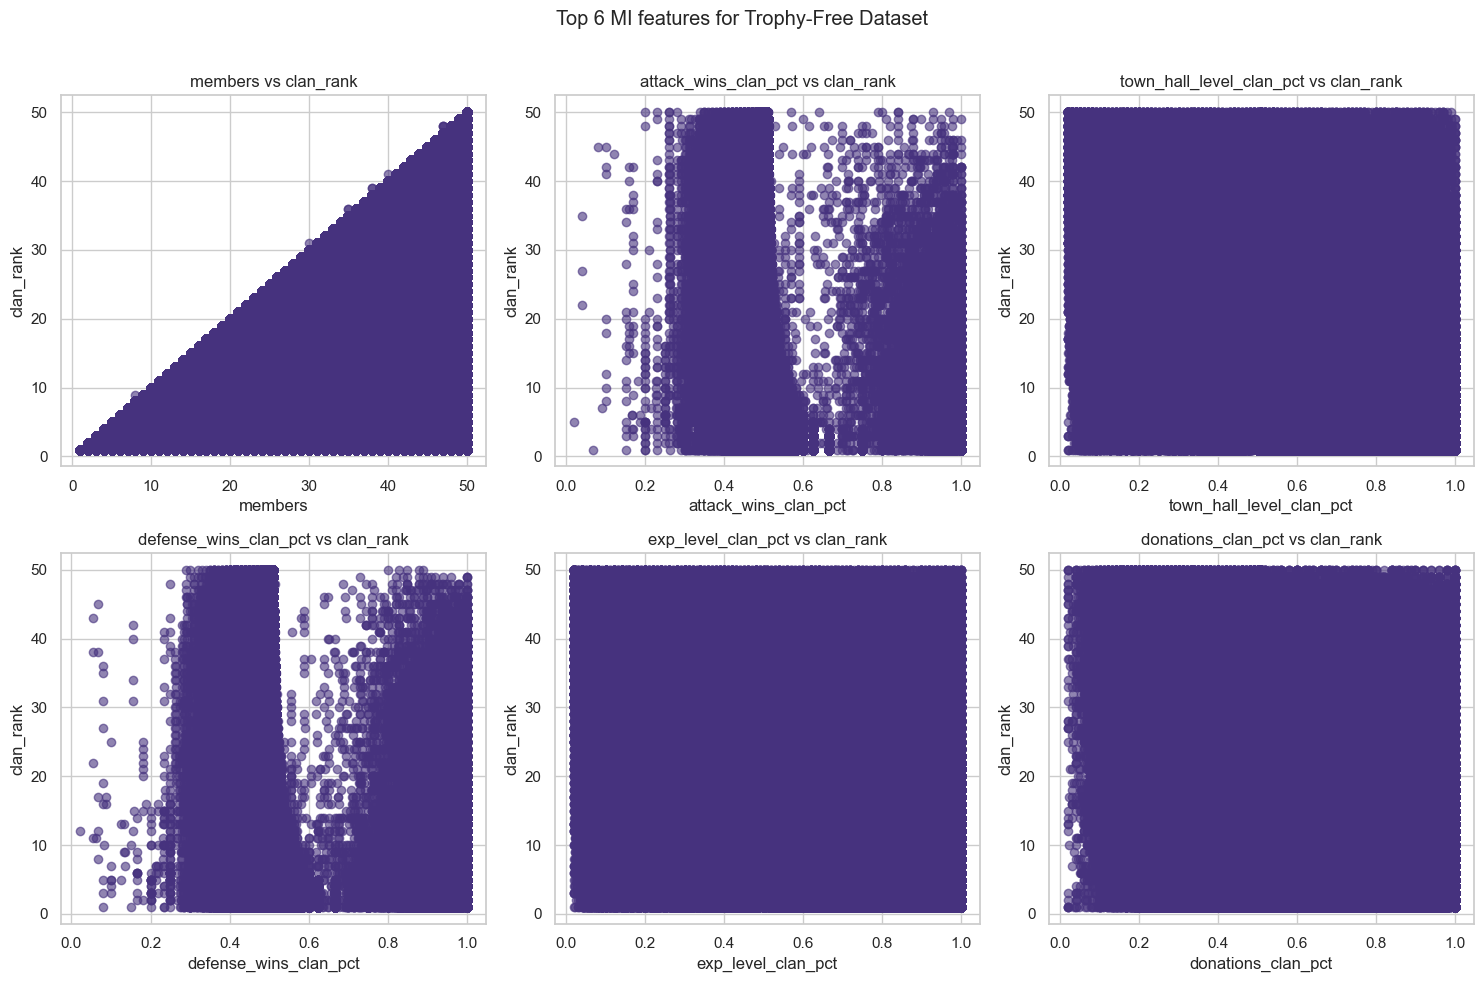

In [5]:
# === 5. Feature-Target Relationships (Regression) ===

def compute_feature_target_metrics(data: pd.DataFrame, name: str) -> dict:
    """Computes MI, Pearson and Spearman correlations for numeric features vs target."""
    # Limpiar filas con target nulo o valores infinitos
    clean_data = data.replace([np.inf, -np.inf], np.nan).dropna(subset=[TARGET]).copy()
    target = clean_data[TARGET]
    
    numeric_cols = clean_data.select_dtypes(include=[np.number]).columns.tolist()
    if TARGET in numeric_cols:
        numeric_cols.remove(TARGET)

    # Impute median temporarily for Mutual Information
    X = clean_data[numeric_cols].copy()
    
    # Eliminar columnas completamente vacías si las hubiera
    X = X.dropna(how='all', axis=1)
    valid_cols = X.columns.tolist()

    for col in valid_cols:
        if X[col].isna().any():
            med = X[col].median()
            X[col] = X[col].fillna(med if pd.notna(med) else 0)

    mi_scores = mutual_info_regression(X, target, random_state=42)
    mi_df = pd.DataFrame({'feature': valid_cols, 'mutual_info': mi_scores})
    mi_df = mi_df.sort_values('mutual_info', ascending=False).reset_index(drop=True)

    pearson = []
    spearman = []
    for col in valid_cols:
        pearson_r = clean_data[col].corr(target, method='pearson')
        spearman_r = clean_data[col].corr(target, method='spearman')
        pearson.append((col, pearson_r))
        spearman.append((col, spearman_r))

    pearson_df = pd.DataFrame(pearson, columns=['feature', 'pearson_r']).sort_values('pearson_r', key=lambda s: s.abs(), ascending=False).reset_index(drop=True)
    spearman_df = pd.DataFrame(spearman, columns=['feature', 'spearman_r']).sort_values('spearman_r', key=lambda s: s.abs(), ascending=False).reset_index(drop=True)

    print('')
    print(f'=== Feature-target metrics for {name} ===')
    print('Top 10 Mutual Information:')
    display(mi_df.head(10))
    print('')
    print('Top 10 Pearson correlation:')
    display(pearson_df.head(10))
    print('')
    print('Top 10 Spearman correlation:')
    display(spearman_df.head(10))

    # Scatter plots for top 6 MI features
    top_features = mi_df.head(6)['feature'].tolist()
    if top_features:
        fig, axes = plt.subplots(2, 3, figsize=(15, 10))
        axes = axes.flatten()
        for ax, var in zip(axes, top_features):
            ax.scatter(clean_data[var], clean_data[TARGET], alpha=0.6)
            ax.set_title(f'{var} vs clan_rank')
            ax.set_xlabel(var)
            ax.set_ylabel(TARGET)
        for ax in axes[len(top_features):]:
            ax.axis('off')
        plt.suptitle(f'Top 6 MI features for {name}')
        plt.tight_layout(rect=[0, 0, 1, 0.97])
        plt.show()

    return {'mi': mi_df, 'pearson': pearson_df, 'spearman': spearman_df}

metrics_full = compute_feature_target_metrics(df_full, 'Full Dataset')
metrics_no_trophies = compute_feature_target_metrics(df_no_trophies, 'Trophy-Free Dataset')

## 6. Multicollinearity and Redundancy

Pearson and Spearman correlation matrices are computed among numerical predictors. Feature pairs exceeding |r| > 0.85 are reported and visual heatmaps are shown.


=== Collinearity report for Full Dataset ===
Pairs with |Pearson| > 0.85:


,feature_1,feature_2,corr
0,town_hall_level,exp_level,0.891220
1,exp_level,builder_base_trophies,0.873612
2,exp_level,best_trophies,0.934167
3,exp_level,builder_hall_level,0.851683
4,builder_base_trophies,builder_hall_level,0.892938
...,...,...,...
96,donations,donations_diff_from_clan_mean,0.980155
97,donation_balance,donations_diff_from_clan_mean,0.981631
98,attack_wins,attack_wins_diff_from_clan_mean,0.921821
99,combat_activity_total,attack_wins_diff_from_clan_mean,0.917247



Pairs with |Spearman| > 0.85:


,feature_1,feature_2,corr
0,town_hall_level,exp_level,0.897365
1,exp_level,builder_base_trophies,0.889479
2,exp_level,best_trophies,0.939114
3,exp_level,war_stars,0.879204
4,town_hall_level,builder_hall_level,0.850558
...,...,...,...
134,war_stars_ratio_to_clan_mean,war_stars_clan_pct,0.888435
135,attack_wins,attack_wins_ratio_to_clan_mean,0.999872
136,defense_wins,defense_wins_ratio_to_clan_mean,0.999722
137,combat_activity_total,defense_wins_ratio_to_clan_mean,0.941415


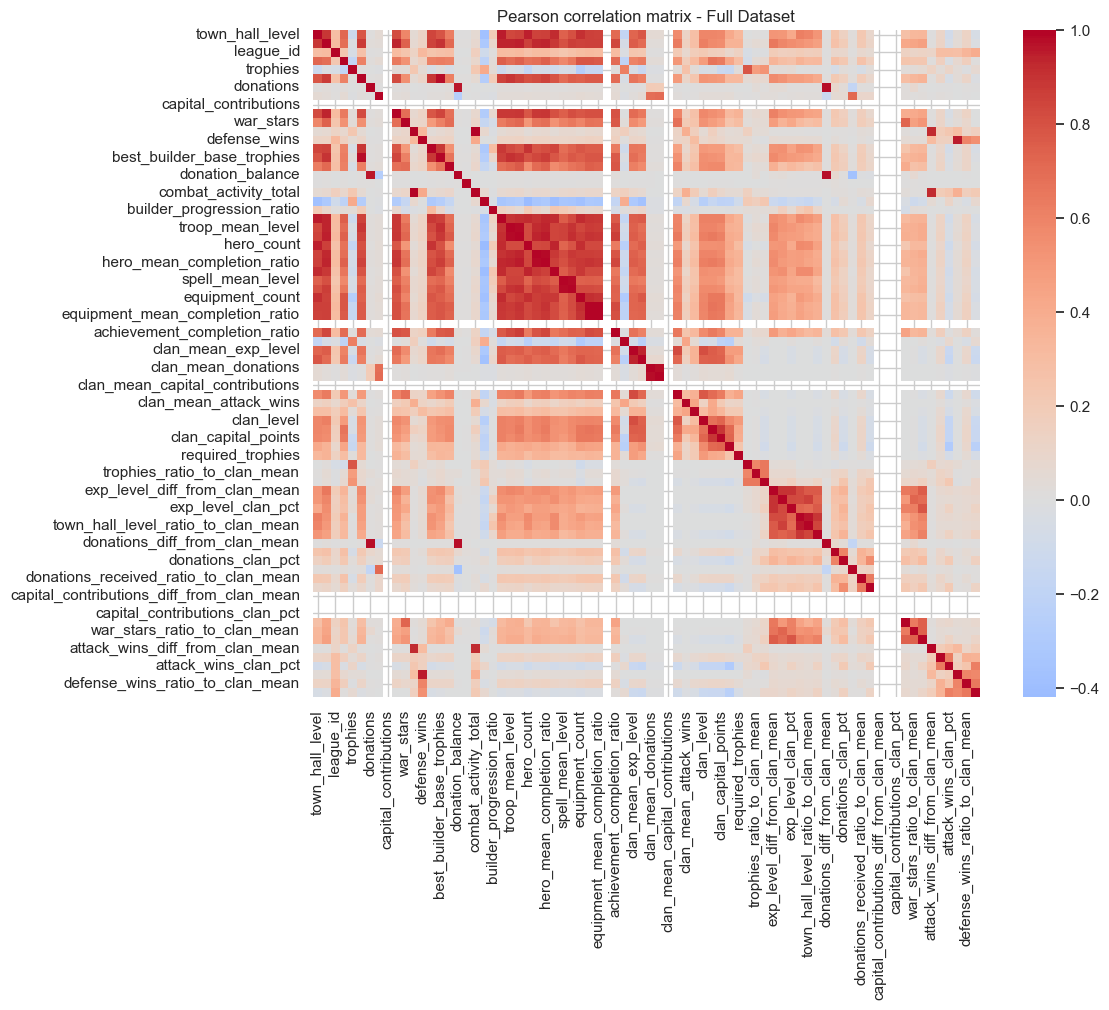

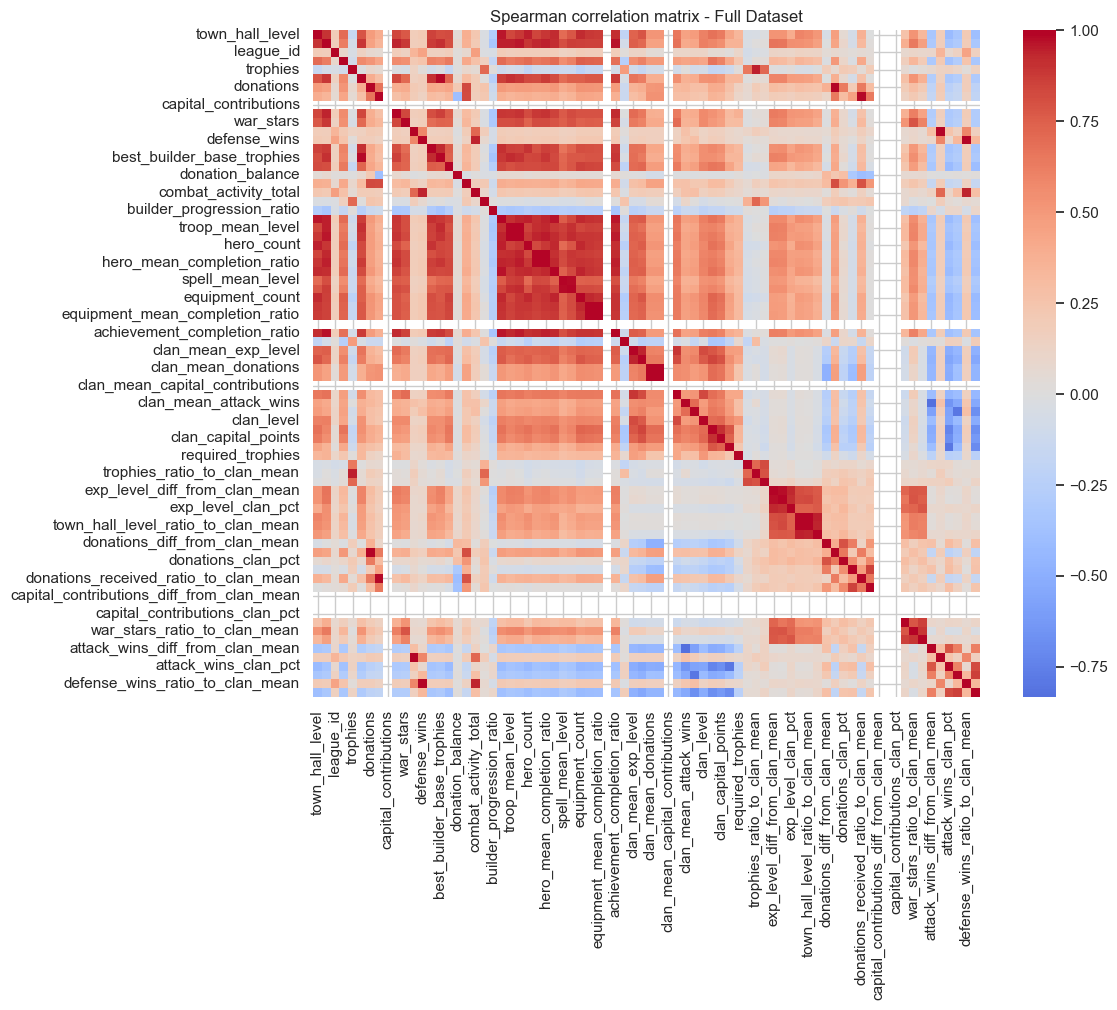


=== Collinearity report for Trophy-Free Dataset ===
Pairs with |Pearson| > 0.85:


,feature_1,feature_2,corr
0,town_hall_level,exp_level,0.891220
1,exp_level,builder_base_trophies,0.873612
2,exp_level,builder_hall_level,0.851683
3,builder_base_trophies,builder_hall_level,0.892938
4,exp_level,best_builder_base_trophies,0.895712
...,...,...,...
90,donations,donations_diff_from_clan_mean,0.980155
91,donation_balance,donations_diff_from_clan_mean,0.981631
92,attack_wins,attack_wins_diff_from_clan_mean,0.921821
93,combat_activity_total,attack_wins_diff_from_clan_mean,0.917247



Pairs with |Spearman| > 0.85:


,feature_1,feature_2,corr
0,town_hall_level,exp_level,0.897365
1,exp_level,builder_base_trophies,0.889479
2,exp_level,war_stars,0.879204
3,town_hall_level,builder_hall_level,0.850558
4,exp_level,builder_hall_level,0.873722
...,...,...,...
124,war_stars_ratio_to_clan_mean,war_stars_clan_pct,0.888435
125,attack_wins,attack_wins_ratio_to_clan_mean,0.999872
126,defense_wins,defense_wins_ratio_to_clan_mean,0.999722
127,combat_activity_total,defense_wins_ratio_to_clan_mean,0.941415


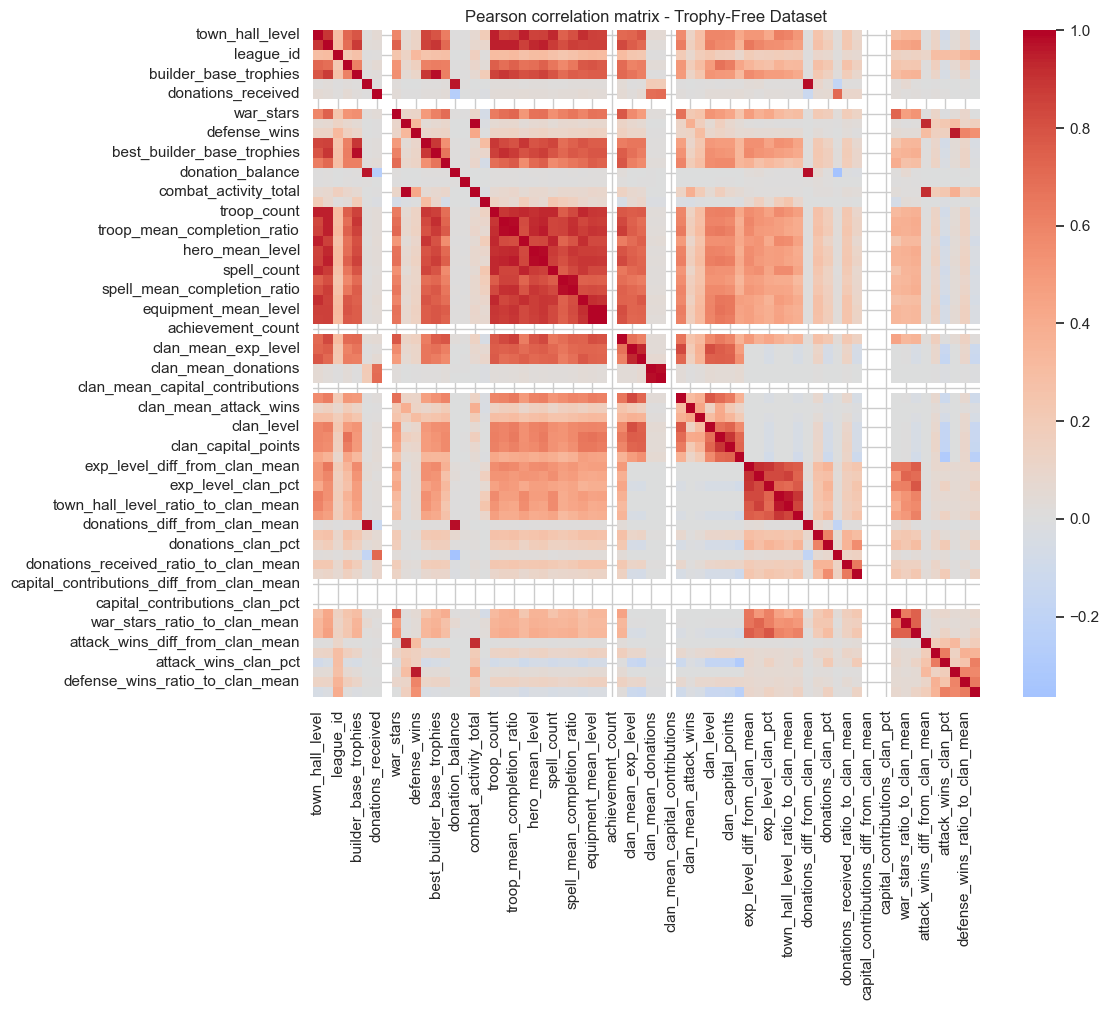

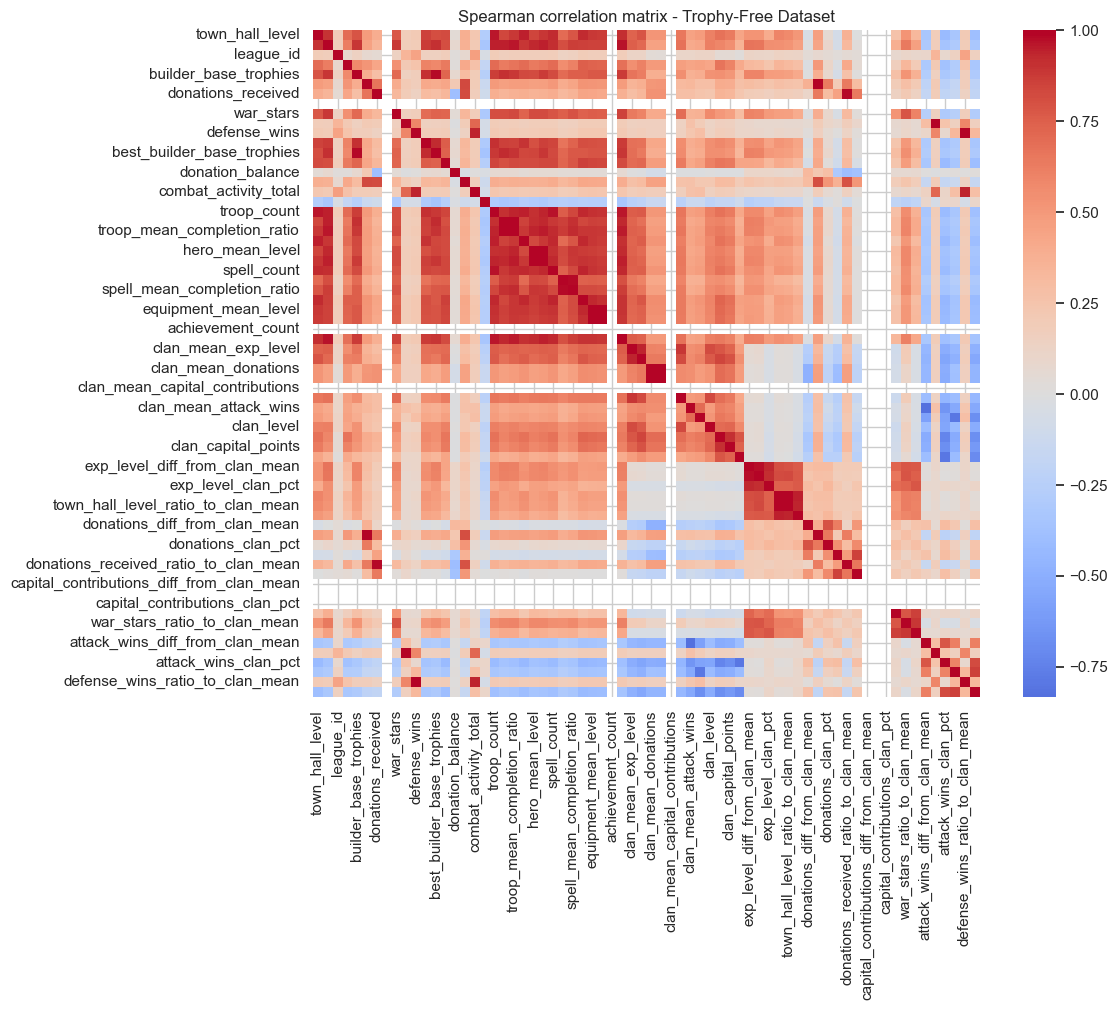

In [6]:
# === 6. Multicollinearity and Redundancy ===

def collinearity_report(data: pd.DataFrame, name: str) -> None:
    """Prints high-correlation pairs and displays correlation heatmaps."""
    numeric_cols = data.select_dtypes(include=[np.number]).columns.tolist()
    if TARGET in numeric_cols:
        numeric_cols.remove(TARGET)
    corr_data = data[numeric_cols].copy().replace([np.inf, -np.inf], np.nan)
    for col in corr_data.columns:
        if corr_data[col].isna().any():
            corr_data[col] = corr_data[col].fillna(corr_data[col].median())

    pearson_corr = corr_data.corr(method='pearson')
    spearman_corr = corr_data.corr(method='spearman')

    threshold = 0.85

    def get_high_corr_pairs(corr_matrix):
        upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
        pairs = []
        for col in upper.columns:
            for idx in upper.index:
                val = upper.loc[idx, col]
                if pd.notna(val) and abs(val) > threshold:
                    pairs.append((idx, col, val))
        return pd.DataFrame(pairs, columns=['feature_1', 'feature_2', 'corr'])

    pearson_pairs = get_high_corr_pairs(pearson_corr)
    spearman_pairs = get_high_corr_pairs(spearman_corr)

    print('')
    print(f'=== Collinearity report for {name} ===')
    print(f'Pairs with |Pearson| > {threshold}:')
    display(pearson_pairs if len(pearson_pairs) > 0 else None)
    print('')
    print(f'Pairs with |Spearman| > {threshold}:')
    display(spearman_pairs if len(spearman_pairs) > 0 else None)

    plt.figure(figsize=(12, 10))
    sns.heatmap(pearson_corr, annot=False, cmap='coolwarm', center=0, square=True)
    plt.title(f'Pearson correlation matrix - {name}')
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(12, 10))
    sns.heatmap(spearman_corr, annot=False, cmap='coolwarm', center=0, square=True)
    plt.title(f'Spearman correlation matrix - {name}')
    plt.tight_layout()
    plt.show()

collinearity_report(df_full, 'Full Dataset')
collinearity_report(df_no_trophies, 'Trophy-Free Dataset')

## 7. Outlier and Extreme Case Detection

IQR-based outlier percentages are reported for every numerical feature. The top 10 extreme records for influential features are inspected qualitatively.

In [7]:
# === 7. Outlier and Extreme Case Detection ===

def iqr_outlier_report(data: pd.DataFrame, name: str) -> pd.DataFrame:
    """Computes IQR outlier percentages for all numerical features."""
    numeric_cols = data.select_dtypes(include=[np.number]).columns.tolist()
    if TARGET in numeric_cols:
        numeric_cols.remove(TARGET)
    records = []
    for col in numeric_cols:
        q1 = data[col].quantile(0.25)
        q3 = data[col].quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        mask = (data[col] < lower_bound) | (data[col] > upper_bound)
        records.append({
            'feature': col,
            'q1': q1,
            'q3': q3,
            'IQR': iqr,
            'lower_bound': lower_bound,
            'upper_bound': upper_bound,
            'n_outliers': int(mask.sum()),
            'pct_outliers': 100.0 * mask.sum() / len(data)
        })
    report = pd.DataFrame(records).sort_values('n_outliers', ascending=False)
    print('')
    print(f'=== IQR outlier report for {name} ===')
    display(report)
    return report

outliers_full = iqr_outlier_report(df_full, 'Full Dataset')
outliers_no_trophies = iqr_outlier_report(df_no_trophies, 'Trophy-Free Dataset')

# Qualitative inspection of top 10 extreme records for influential features
for variant_name, data in [('Full', df_full), ('Trophy-Free', df_no_trophies)]:
    print('')
    print(f'=== Top 10 extreme records for {variant_name} variant ===')
    for var in ['donations', 'trophies', 'attack_wins']:
        if var in data.columns:
            top_vals = data.nlargest(10, var)[[var, TARGET]].reset_index(drop=True)
            print(f'Extreme values for {var}:')
            display(top_vals)


=== IQR outlier report for Full Dataset ===


,feature,q1,q3,IQR,lower_bound,upper_bound,n_outliers,pct_outliers
16,donation_balance,0.000000,0.000000,0.000000,0.000000,0.000000,285424,34.084100
70,attack_wins_diff_from_clan_mean,-0.045455,0.000000,0.045455,-0.113636,0.068182,206748,24.688952
6,donations,0.000000,10.000000,10.000000,-15.000000,25.000000,202411,24.171046
59,donations_ratio_to_clan_mean,0.000000,0.093371,0.093371,-0.140056,0.233427,196596,23.476644
49,trophies_diff_from_clan_mean,-163.257143,57.800000,221.057143,-494.842857,389.385714,172236,20.567678
...,...,...,...,...,...,...,...,...
51,trophies_clan_pct,0.333333,0.737171,0.403838,-0.272423,1.342928,0,0.000000
66,capital_contributions_clan_pct,0.000000,0.000000,0.000000,0.000000,0.000000,0,0.000000
65,capital_contributions_ratio_to_clan_mean,0.000000,0.000000,0.000000,0.000000,0.000000,0,0.000000
64,capital_contributions_diff_from_clan_mean,0.000000,0.000000,0.000000,0.000000,0.000000,0,0.000000



=== IQR outlier report for Trophy-Free Dataset ===


,feature,q1,q3,IQR,lower_bound,upper_bound,n_outliers,pct_outliers
14,donation_balance,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,285424,34.084100
62,attack_wins_diff_from_clan_mean,-4.545455e-02,0.000000e+00,0.045455,-1.136364e-01,6.818182e-02,206748,24.688952
5,donations,0.000000e+00,1.000000e+01,10.000000,-1.500000e+01,2.500000e+01,202411,24.171046
51,donations_ratio_to_clan_mean,0.000000e+00,9.337068e-02,0.093371,-1.400560e-01,2.334267e-01,196596,23.476644
2,league_id,2.900000e+07,2.900000e+07,0.000000,2.900000e+07,2.900000e+07,169465,20.236777
...,...,...,...,...,...,...,...,...
43,members,1.400000e+01,3.900000e+01,25.000000,-2.350000e+01,7.650000e+01,0,0.000000
58,capital_contributions_clan_pct,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0,0.000000
57,capital_contributions_ratio_to_clan_mean,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0,0.000000
56,capital_contributions_diff_from_clan_mean,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0,0.000000



=== Top 10 extreme records for Full variant ===
Extreme values for donations:


...

,attack_wins,clan_rank
0,913,1
1,910,3
2,910,7
3,908,2
4,907,5
5,905,10
6,905,4
7,902,6
8,902,6
9,902,1



=== Top 10 extreme records for Trophy-Free variant ===
Extreme values for donations:


,donations,clan_rank
0,3161641,1
1,2400715,2
2,2368337,1
3,1266761,1
4,1139948,1
5,1075534,1
6,833804,1
7,757437,5
8,573620,5
9,535634,5


Extreme values for attack_wins:


,attack_wins,clan_rank
0,913,1
1,910,3
2,910,7
3,908,2
4,907,5
5,905,10
6,905,4
7,902,6
8,902,6
9,902,1


## 8. Modeling Implications and Executive Summary

The findings are consolidated into an executable summary dictionary and explicit preprocessing, validation, pruning, and modeling recommendations are provided.

In [9]:
# === 8. Summary dictionary and recommendations ===
target = df_full[TARGET]
max_pct = (target.value_counts(normalize=True) * 100).max()
min_pct = (target.value_counts(normalize=True) * 100).min()
summary = {
    'target': TARGET,
    'full_rows': df_full.shape[0],
    'full_cols': df_full.shape[1],
    'trophy_free_rows': df_no_trophies.shape[0],
    'trophy_free_cols': df_no_trophies.shape[1],
    'trophy_columns_removed': trophy_cols,
    'target_skewness': float(stats.skew(target.dropna())),
    'target_kurtosis': float(stats.kurtosis(target.dropna())),
    'target_imbalance_ratio': float(max_pct / max(min_pct, 1e-9)) if min_pct > 0 else float('inf'),
    'top_mi_features_full': metrics_full['mi'].head(10).to_dict('records'),
    'top_mi_features_trophy_free': metrics_no_trophies['mi'].head(10).to_dict('records'),
    'full_high_pearson_pairs': collinearity_report_df_full if 'collinearity_report_df_full' in globals() else [],
    'trophy_free_high_pearson_pairs': collinearity_report_df_no_trophies if 'collinearity_report_df_no_trophies' in globals() else [],
    'outlier_max_pct_full': float(outliers_full['pct_outliers'].max()) if len(outliers_full) > 0 else 0.0,
    'outlier_max_pct_trophy_free': float(outliers_no_trophies['pct_outliers'].max()) if len(outliers_no_trophies) > 0 else 0.0
}
print('=== EXECUTIVE SUMMARY EDA P2 ===')
for k, v in summary.items():
    print(f'{k}: {v}')

=== EXECUTIVE SUMMARY EDA P2 ===
target: clan_rank
full_rows: 837411
full_cols: 87
trophy_free_rows: 837411
trophy_free_cols: 79
trophy_columns_removed: ['required_trophies', 'best_trophies', 'trophies_diff_from_clan_mean', 'trophies', 'clan_mean_trophies', 'progression_ratio_trophies', 'trophies_clan_pct', 'trophies_ratio_to_clan_mean']
target_skewness: 1.0297496835595223
target_kurtosis: 0.3159766696334416
target_imbalance_ratio: 58.93189557321226
top_mi_features_full: [{'feature': 'members', 'mutual_info': 0.46767648354904434}, {'feature': 'attack_wins_clan_pct', 'mutual_info': 0.42305198249539266}, {'feature': 'town_hall_level_clan_pct', 'mutual_info': 0.41941942863882}, {'feature': 'defense_wins_clan_pct', 'mutual_info': 0.38832643953887214}, {'feature': 'exp_level_clan_pct', 'mutual_info': 0.35215971151390946}, {'feature': 'donations_clan_pct', 'mutual_info': 0.34875990034386106}, {'feature': 'donations_received_clan_pct', 'mutual_info': 0.30828640101531235}, {'feature': 'town_ha

### Preprocessing Recommendations

- **Imputation**
  - Numeric: median for highly skewed features or when outliers are prevalent; otherwise, mean.
  - Categorical: most frequent category (mode); consider an explicit `"missing"` category if the missing rate is high.
  - Drop columns with more than 40-50% missing values, unless they carry critical domain information.

- **Transformations**
  - Apply `log1p` to severely skewed predictors (`|skew| > 1`) such as donations, loot metrics, or trophy counts.
  - Use `RobustScaler` for features with extreme outliers; `StandardScaler` for the rest.

- **Target Transformation**
  - Based on the skewness diagnostic, transform `clan_rank` with `log1p` if `|skew| > 0.5` and evaluate inverse transform for interpretation.

### Cross-Validation Strategy

- **StratifiedKFold on rank bins**  
  - Bin target values into quantile-based groups and use these bins as stratification labels to preserve distribution in each fold.
- **GroupKFold**  
  - If multiple rows share the same clan entity, use `clan_tag` as the grouping variable to prevent data leakage.
- **Metrics**  
  - `MAE`: scales interpretability in original units.  
  - `RMSE`: penalizes large errors more strongly.  
  - `R²`: proportion of variance explained.

### Feature Pruning

- Remove zero-variance and nearly constant features (`mode frequency >= 0.95`).
- For each collinear pair (`|Pearson| > 0.85` or `|Spearman| > 0.85`), retain the feature with higher Mutual Information.
- If MI is very close, prefer the feature with lower measurement cost or higher interpretability.
- For tree-based models, correlation pruning is less critical, but can reduce training time and improve stability.

### Recommended Baseline Models

1. **Ridge Regression**  
   - `Ridge(alpha=1.0, positive=False)`  
   - Good baseline for regularized linear relationships, especially with high-dimensional data.

2. **Random Forest Regressor**  
   - `RandomForestRegressor(n_estimators=200, random_state=42, max_depth=None)`  
   - Robust to non-linear patterns and outliers; provides feature importance.

3. **XGBoost Regressor**  
   - `XGBRegressor(objective='reg:squarederror', n_estimators=200, learning_rate=0.05, random_state=42)`  
   - Strong performance with hyperparameter tuning and early stopping.

The above recommendations should directly feed the modeling phase for Problem 2.